In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
data = pd.read_excel("ca11-03homes.xls", engine="xlrd")

In [4]:
data.head()

,Obs,Price,SqFt,BedRooms,Baths,Garage,Zip
0,1,52900,932,1,1.0,0,4
1,2,61500,780,3,1.0,0,5
2,3,62000,1500,3,1.0,0,9
3,4,62900,760,2,1.0,0,4
4,5,64900,900,2,1.0,0,4


In [5]:
data.isnull().sum()

Obs         0
Price       0
SqFt        0
BedRooms    0
Baths       0
Garage      0
Zip         0
dtype: int64

In [6]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

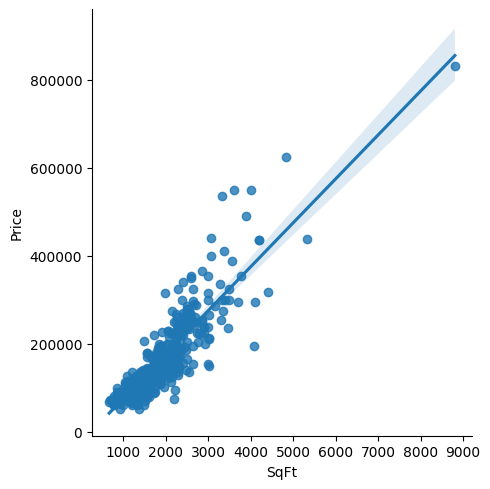

In [7]:
sns.lmplot(x='SqFt', y = 'Price', data=data)
plt.show()

C:\Users\kunal  kumar  pandey\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\kunal  kumar  pandey\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\kunal  kumar  pandey\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


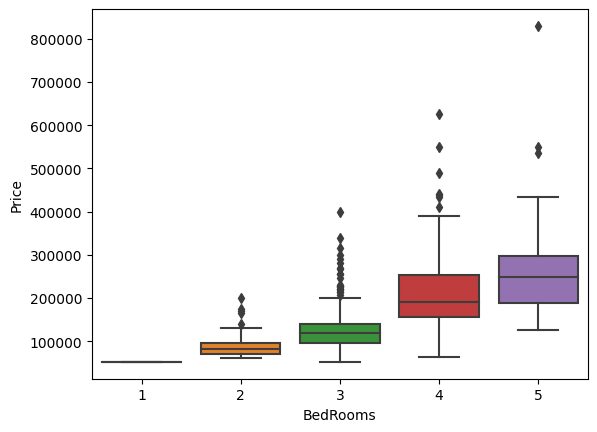

In [8]:
sns.boxplot(x = 'BedRooms' , y = 'Price' , data=data)
plt.show()

C:\Users\kunal  kumar  pandey\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\kunal  kumar  pandey\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\kunal  kumar  pandey\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


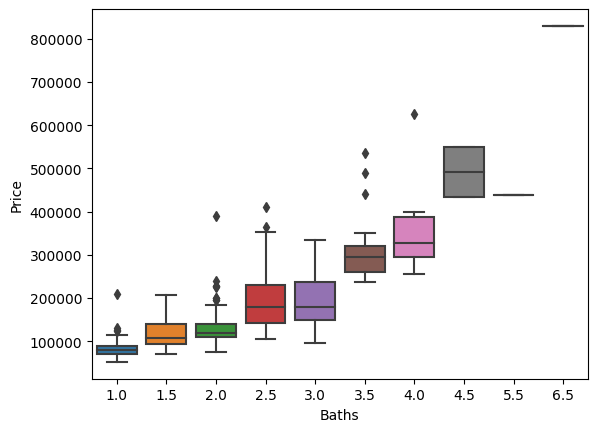

In [9]:
sns.boxplot(x = 'Baths' , y = 'Price' , data=data)
plt.show()

In [11]:
q3 = data['Price'].quantile(0.75)
q1 = data['Price'].quantile(0.25)

In [12]:
iqr = q3 - q1

In [13]:
iqr

80000.0

In [14]:
ul = q3 + (1.25 * iqr)
ll = q1 - (1.25 * iqr)

In [15]:
ul

284900.0

In [16]:
ll

4900.0

In [18]:
upper = np.where(data['Price'] >= ul)
lower = np.where(data['Price'] <= ll)

In [19]:
data.drop(upper[0] , inplace = True)
data.drop(lower[0] , inplace = True)

In [20]:
x = data.iloc[: , 2:5].values
y = data.iloc[: , 1].values

In [21]:
x

array([[9.320e+02, 1.000e+00, 1.000e+00],
       [7.800e+02, 3.000e+00, 1.000e+00],
       [1.500e+03, 3.000e+00, 1.000e+00],
       ...,
       [3.016e+03, 4.000e+00, 2.500e+00],
       [2.407e+03, 3.000e+00, 2.500e+00],
       [2.161e+03, 4.000e+00, 3.500e+00]])

In [25]:
from sklearn.model_selection import train_test_split
x_train , x_test, y_train , y_teast = train_test_split(x , y , test_size= 0.3 , random_state = 0)

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
reg = LinearRegression()

In [28]:
reg.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
from sklearn.metrics import r2_score

In [31]:
reg.score(x_test, y_teast)

0.7558760022489226

In [32]:
reg.predict([[780 , 3,1]])

array([56167.46220051])

In [33]:
import joblib
joblib.dump(reg ,"House_price_predication.pkl")

['House_price_predication.pkl']

In [34]:
load = joblib.load("House_price_predication.pkl")

In [35]:
load.predict([[1500 ,3 ,1] ,[2000 , 4, 4]])

array([106372.04502062, 196276.73699648])